Modern LLM'lerin temelinde Transformer mimarisi bulunur. 2017'de Google tarafından yayınlanan "Attention Is All You Need" makalesiyle tanıtılmıştır.

https://arxiv.org/abs/1706.03762

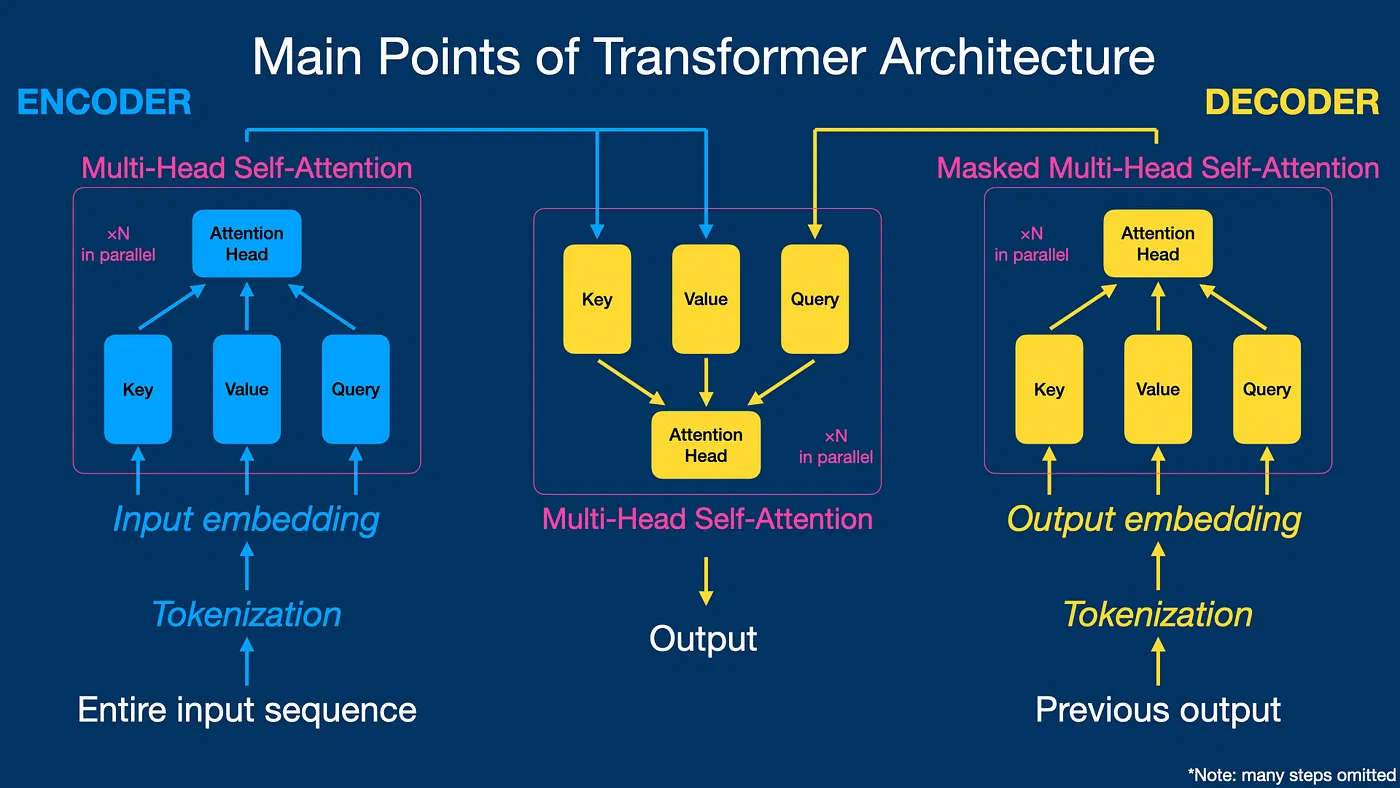

Transformer'dan önce RNN'ler vardı. RNN bir cümleyi soldan sağa, kelime kelime okuyordu — tıpkı bir kişinin uzun bir mektubu kelime kelime okuması gibi. Bu hem yavaştı hem de cümlenin başındaki bilgiyi sonlara gelince unutuyordu. Transformer dedi ki: "Neden tüm kelimelere aynı anda bakmıyorum?"


**Temel Fikir: Self-Attention (Öz-Dikkat)**

Bir cümle düşünün: "Kedi süt içti çünkü o açtı."
İnsan olarak "o" kelimesini gördüğünüzde hemen anlarsınız ki "o" = "kedi". İşte self-attention tam olarak bunu yapıyor. Her kelime diğer tüm kelimelere bakıp soruyor: "Seninle ne kadar ilişkiliyim?"

Bunu üç kavramla yapar. **Query (soru soran)**, **Key (cevap veren)** ve **Value (gerçek bilgi)**. "O" kelimesi bir Query fırlatır: "Ben kimi temsil ediyorum?" Tüm kelimeler Key'leriyle cevap verir. "Kedi" en yüksek skoru alır, dolayısıyla "o" kelimesi "kedi"nin Value bilgisini en çok alır. Matematiksel olarak bu, Query ile Key'in çarpılıp softmax'ten geçirilmesi ve Value ile ağırlıklandırılmasıdır.

**Multi-Head Attention: Farklı Gözlerle Bakmak**
Tek bir attention yetmez çünkü dilde birden fazla ilişki türü var. Bir head özne-yüklem ilişkisine bakarken, başka bir head sıfat-isim ilişkisini, bir diğeri zamir referansını öğrenebilir. Bu yüzden birden fazla attention head paralel çalışır ve sonra sonuçları birleştirilir.

**Positional Encoding: Sıra Bilgisi**
Attention tüm kelimelere aynı anda baktığı için doğal olarak sıra kavramı yoktur. "Kedi fareyi kovaladı" ile "Fare kediyi kovaladı" aynı kelimelerden oluşur ama anlamı çok farklıdır. Bu yüzden her pozisyona sinüs ve kosinüs fonksiyonlarıyla bir konum bilgisi eklenir. Embedding vektörüne bu pozisyon bilgisi toplanır ve model "bu kelime 3. sırada" bilgisini de almış olur.

**Encoder ve Decoder**
Orijinal Transformer iki parçadan oluşur.
**Encoder** girdi cümlesini anlayıp zengin bir temsil üretir. Her encoder katmanı iki şey yapar: önce multi-head self-attention ile kelimeler arası ilişkileri yakalar, sonra bir feed-forward network ile bu bilgiyi işler.

**Decoder** ise çıktıyı üretir. Encoder'a ek olarak iki farkı vardır. Birincisi, masked attention kullanır — yani bir kelimeyi üretirken sadece önceki kelimelere bakabilir, geleceği göremez. İkincisi, cross-attention ile encoder çıktısına bakar. "Encoder ne anladı?" diye sorar ve o bilgiyi kullanarak bir sonraki kelimeyi tahmin eder.

**Feed-Forward Network**
Her attention katmanından sonra bir FFN gelir. Bu basitçe iki lineer katman arasında ReLU aktivasyonu olan bir yapıdır. Attention "hangi kelimelere dikkat edeyim" sorusuna cevap verirken, FFN "bu bilgiyi nasıl işleyeyim" sorusuna cevap verir.

Çıktı: Nasıl Kelime Üretilir?
Decoder'ın son çıktısı bir lineer katmandan geçip vocab boyutuna dönüştürülür, sonra softmax ile olasılık dağılımına çevrilir. En yüksek olasılıklı token bir sonraki kelime olarak seçilir. Bu işlem her seferinde bir token üretir ve üretilen token tekrar girdi olarak verilip süreç tekrarlanır buna **autoregressive generation** denir.




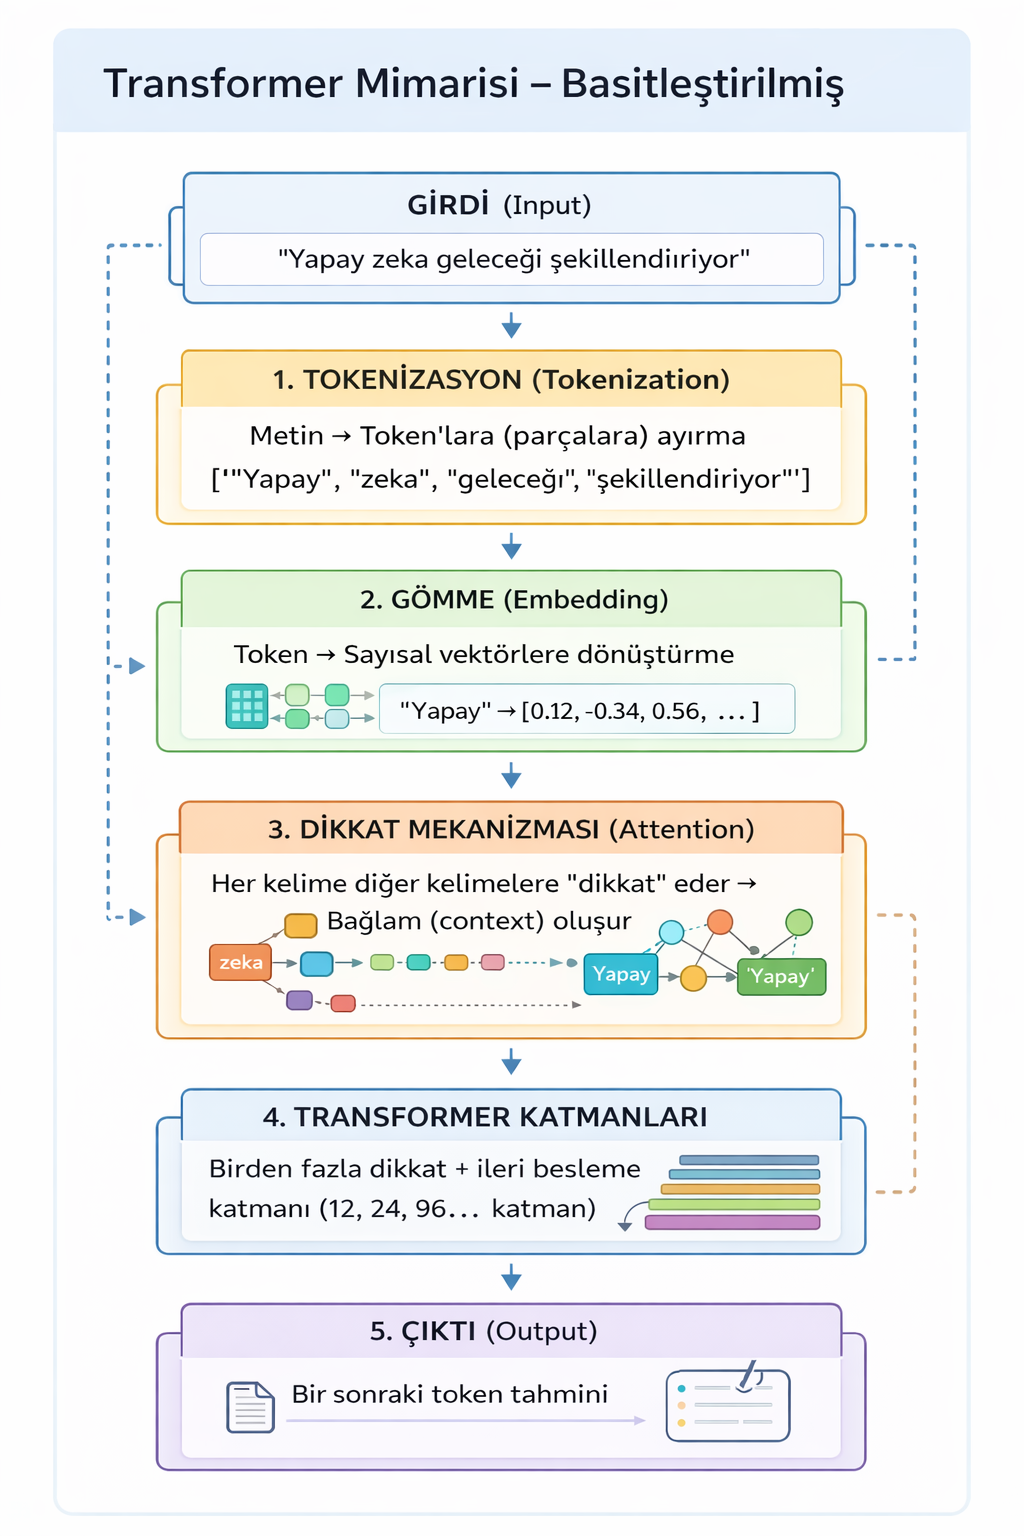

### 1. Girdi (Input)

Transformer mimarisi, ilk olarak ham metni girdi olarak alır.
Örneğin:

“Yapay zeka geleceği şekillendiriyor”

Bu aşamada model, metnin anlamını bilmez. Girdi yalnızca bir karakter dizisidir ve sayısal işleme uygun değildir.

### 2. Tokenizasyon (Tokenization)

Girdi metni, daha küçük parçalara yani token’lara ayrılır.

Örnek token listesi:
["Yapay", "zeka", "geleceği", "şekillendiriyor"]

Tokenizasyonun amacı:

- Metni modelin işleyebileceği birimlere bölmek

- Her parçayı daha sonra sayısal temsile dönüştürmek

- Token’lar her zaman kelime olmak zorunda değildir; alt kelimeler veya ekler de olabilir.

### 3. Gömme (Embedding)

Her token, sabit boyutlu sayısal bir vektöre dönüştürülür.

Örnek:
"Yapay" → [0.12, -0.34, 0.56, …]

Bu vektörler:

- Kelimelerin anlamsal özelliklerini temsil eder

- Anlamı benzer kelimeler, vektör uzayında birbirine daha yakın konumlanır

- Bu aşamadan sonra metin, tamamen sayısal hale gelmiş olur.

### 4. Dikkat Mekanizması (Attention)

Attention mekanizması, her token’ın diğer tüm token’larla olan ilişkisini hesaplar.

Bu aşamada model şunu öğrenir:

Hangi kelime, hangi kelimeyle ne kadar ilişkilidir

Bir kelimenin anlamı, cümledeki diğer kelimelere bağlı olarak nasıl değişir

**Örneğin:**

- “zeka” kelimesi, “yapay” kelimesine yüksek dikkat verebilir

- “geleceği” ve “şekillendiriyor” arasında güçlü bir bağ kurulabilir

- Bu işlem sonucunda bağlamsal temsil (context) oluşur.

### 5. Transformer Katmanları

Attention ve ileri beslemeli ağlar, tek bir kez değil, birden fazla katmanda tekrar edilir.

**Her transformer katmanı:**

- Çoklu dikkat mekanizması (Multi-Head Attention)

- İleri beslemeli sinir ağı (Feed Forward Network)

- Normalizasyon ve artık bağlantılar (Residual Connections)

içerir.

**Katman sayısı arttıkça model:**

- Daha karmaşık ilişkileri öğrenir

- Daha soyut ve derin anlamlar çıkarır

### 6. Çıktı (Output)

Son aşamada model, mevcut bağlama göre bir sonraki token’ı tahmin eder.

Örnek:
“Yapay zeka geleceği” → “şekillendiriyor”

Transformer tabanlı dil modellerinin temel çalışma prensibi, her adımda bir sonraki en olası token’ı tahmin etmektir. Bu basit prensip, büyük veri ve derin katmanlarla birleştiğinde güçlü dil üretim yeteneklerine dönüşür.

In [ ]:
# Gerekli kütüphanelerin kurulumu
!pip install torch numpy matplotlib transformers tiktoken sentencepiece -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

print(" Kütüphaneler başarıyla yüklendi!")
print(f"PyTorch versiyon: {torch.__version__}")

---

#  1: Tokenization (Tokenleştirme)

## Nedir?

Bilgisayarlar metni doğrudan anlayamaz. Tokenization, metni bilgisayarın işleyebileceği **küçük parçalara (token)** ayırma işlemidir.

## Token Nedir?

Token, metnin en küçük anlamlı birimidir. Bir token şunlardan biri olabilir:
- Bir **kelime** → `"merhaba"` → 1 token
- Bir **alt-kelime (subword)** → `"oynuyordum"` → `"oynu"` + `"yord"` + `"um"` (3 token)
- Bir **karakter** → `"a"`, `"b"`, `"c"` → her biri 1 token

## Neden Alt-Kelime (Subword) Tokenization?

| Yöntem | Avantaj | Dezavantaj |
|--------|---------|------------|
| **Kelime bazlı** | Anlaşılır | Sözlük çok büyür, nadir kelimeler sorun olur |
| **Karakter bazlı** | Küçük sözlük | Anlam kaybı, uzun diziler |
| **Alt-kelime (BPE/WordPiece)** |  Dengeli sözlük boyutu | Modern modellerin tercihi |

## Popüler Tokenizer'lar

| Tokenizer | Kullanan Model |
|-----------|---------------|
| **BPE (Byte Pair Encoding)** | GPT-2, GPT-3, GPT-4 |
| **WordPiece** | BERT, DistilBERT |
| **SentencePiece** | T5, LLaMA, Gemma |
| **Tiktoken** | GPT-4, GPT-5 (OpenAI) |

---


### 1.2: Tiktoken (GPT-5 tokenizer'ı)

In [ ]:
import tiktoken

enc = tiktoken.encoding_for_model("gpt-5")

# Türkçe ve İngilizce metinleri karşılaştıralım
metinler = [
    "Yapay zeka dünyayı değiştiriyor",
    "Artificial intelligence is changing the world",
    "Merhaba, bugün hava çok güzel!",
    "Transformer mimarisi çok güçlüdür"
]

print("=" * 70)
print(" GPT-5 Tokenizer (tiktoken) ile Tokenization")
print("=" * 70)

for metin in metinler:
    token_idleri = enc.encode(metin)
    tokenlar = [enc.decode([tid]) for tid in token_idleri]

    print(f"\n Metin: \"{metin}\"")
    print(f"Token sayısı: {len(token_idleri)}")
    print(f" Token'lar: {tokenlar}")
    print(f" Token ID'leri: {token_idleri}")
    print("-" * 70)

---

#  Bölüm 2: Embedding (Gömme)

## Nedir?

Embedding, token ID'lerini **anlamlı sayısal vektörlere** dönüştürme işlemidir.

## Neden Gerekli?

```
Token ID: 42  →  Sadece bir numara, anlam yok
Embedding:  [0.2, -0.5, 0.8, ...]  →  Anlamsal bilgi taşıyan vektör
```

## Temel Fikir

Embedding sayesinde:
- **Benzer anlamlı** kelimeler, vektör uzayında **birbirine yakın** olur
- `"kral"` ve `"kraliçe"` birbirine yakın
- `"kral"` ve `"araba"` birbirinden uzak



---


### 2.1 Basit Embedding: Lookup Table

In [ ]:
# Embedding temelde bir "lookup table" (arama tablosu) dur
# Her token ID'sine karşılık bir vektör döndürür

# Sözlük boyutu: 10 kelime, Embedding boyutu: 4
sozluk_boyutu = 10
embedding_boyutu = 4

# PyTorch'un Embedding katmanı
embedding = nn.Embedding(sozluk_boyutu, embedding_boyutu)

print(" Embedding Tablosu (rastgele başlatılmış):")
print(f"   Sözlük boyutu: {sozluk_boyutu}")
print(f"   Embedding boyutu: {embedding_boyutu}")
print(f"   Toplam parametre: {sozluk_boyutu * embedding_boyutu}")
print()

# Bazı token ID'lerini embedding'e çevirelim
token_idleri = torch.tensor([0, 3, 5, 7])

# Embedding lookup
vektorler = embedding(token_idleri)

print(" Token ID'leri → Embedding Vektörleri:")
print("-" * 50)
for tid, vektor in zip(token_idleri, vektorler):
    print(f"   Token {tid.item()} → {vektor.detach().numpy().round(3)}")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math


class PositionalEncoding(nn.Module):
    """Transformer'a sıralama bilgisi ekleyen katman."""

    def __init__(self, d_model, max_seq_len=512):
        super().__init__()
        self.d_model = d_model

        # Pozisyonel kodlamayı hesapla
        pe = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) # (1, max_seq_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

class TokenEmbedding(nn.Module):
    """Token embedding ve pozisyonel encoding'i birleştiren katman."""

    def __init__(self, sozluk_boyutu, d_model, max_seq_len):
        super().__init__()
        self.token_embedding = nn.Embedding(sozluk_boyutu, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_len)

    def forward(self, x):
        # x: (batch_size, seq_len)
        # Token embedding
        token_emb = self.token_embedding(x)
        # Pozisyonel encoding ekle
        return self.positional_encoding(token_emb)

class MultiHeadAttention(nn.Module):
    """multihead dikkat mekanizması."""

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.d_model = d_model

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.wo = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # (batch_size, seq_len, d_model) -> (batch_size, num_heads, seq_len, d_k)
        q = self.wq(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = self.wk(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = self.wv(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Dikkat skorlarını hesapla
        # (batch_size, num_heads, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9) # Maskeleme

        attention_weights = F.softmax(scores, dim=-1)

        # Dikkat vektörlerini hesapla
        # (batch_size, num_heads, seq_len, d_k)
        output = torch.matmul(attention_weights, v)

        # (batch_size, seq_len, d_model) şekline geri dön
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)

        return self.wo(output), attention_weights

class FeedForwardNet(nn.Module):
    """Konum bazlı ileri beslemeli sinir ağı."""

    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(F.relu(self.linear1(x)))

class TransformerEncoderBlock(nn.Module):
    """Tek bir Transformer Encoder bloğu."""

    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = FeedForwardNet(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-Attention katmanı
        attn_output, attn_weights = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output)) # Residual + Normalizasyon

        # Feed-Forward katmanı
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output)) # Residual + Normalizasyon

        return x, attn_weights

# --- Ana Transformer Encoder Modeli --- #
class TransformerEncoder(nn.Module):
    """Tam bir Transformer Encoder modeli"""

    def __init__(self, sozluk_boyutu, d_model, num_heads, d_ff,
                 num_layers, max_seq_len=512, dropout=0.1):
        super().__init__()

        # Token + Positional Embedding
        self.embedding = TokenEmbedding(sozluk_boyutu, d_model, max_seq_len)
        self.dropout = nn.Dropout(dropout)

        # N tane Encoder katmanı
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        # Son normalizasyon
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # 1. Embedding
        x = self.embedding(x)
        x = self.dropout(x)

        # 2. N encoder katmanından geçir
        all_attention_weights = []
        for layer in self.layers:
            x, attn_w = layer(x, mask)
            all_attention_weights.append(attn_w)

        # 3. Son normalizasyon
        x = self.norm(x)

        return x, all_attention_weights

# Model oluştur - BERT-mini benzeri
config = {
    "sozluk_boyutu": 30_000,  # 30K kelimelik sözlük
    "d_model": 128,           # Embedding boyutu
    "num_heads": 4,           # Attention head sayısı
    "d_ff": 512,              # FFN iç boyutu
    "num_layers": 4,          # Encoder katman sayısı
    "max_seq_len": 512,       # Maksimum dizi uzunluğu
}

model = TransformerEncoder(**config)

# Test
ornek_input = torch.randint(0, config["sozluk_boyutu"], (2, 10))  # batch=2, seq=10
output, attn_weights = model(ornek_input)

print(" Transformer Encoder ")
print("=" * 55)
print(f"   Konfigürasyon:")
for k, v in config.items():
    print(f"     {k}: {v:,}")

toplam_param = sum(p.numel() for p in model.parameters())
print(f"\n    Toplam parametre: {toplam_param:,}")
print(f"    Yaklaşık boyut: {toplam_param * 4 / 1024 / 1024:.1f} MB (float32)")
print(f"\n   Input shape:  {ornek_input.shape}  (batch, seq_len)")
print(f"   Output shape: {output.shape}  (batch, seq_len, d_model)")

print(f"\n\n Gerçek modellerin parametre sayıları:")
print(f"   {'Model':<20s} {'Parametre':>15s} {'d_model':>8s} {'Katman':>7s} {'Head':>5s}")
print(f"   {'-'*60}")
modeller = [
    ("BERT-base", "110M", 768, 12, 12),
    ("BERT-large", "340M", 1024, 24, 16),
    ("GPT-2", "1.5B", 1600, 48, 25),
    ("GPT-3", "175B", 12288, 96, 96),
    ("GPT-5 (tahmini)", "~1.8T", "?", "?", "?"),
    ("LLaMA-2 70B", "70B", 8192, 80, 64),
]
for m in modeller:
    print(f"   {m[0]:<20s} {m[1]:>15s} {str(m[2]):>8s} {str(m[3]):>7s} {str(m[4]):>5s}")

---

#  Bölüm 5: Gerçek Dünya Uygulaması - HuggingFace Transformers

Şimdiye kadar her şeyi sıfırdan kodladık. Pratikte **HuggingFace Transformers** kütüphanesi kullanılır.


### 5.1 Tokenizer Kullanımı

In [ ]:
from transformers import AutoTokenizer

# BERT tokenizer'ı yükle
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

metin = "Transformer models are amazing for NLP tasks!"
encoded = tokenizer(metin, return_tensors="pt")

print("HuggingFace BERT Tokenizer")
print("=" * 60)
print(f" Metin: '{metin}'")
print(f"\n Token ID'leri: {encoded['input_ids'][0].tolist()}")

# Token'ları göster
tokenlar = tokenizer.convert_ids_to_tokens(encoded['input_ids'][0])
print(f" Token'lar: {tokenlar}")
print(f"Token sayısı: {len(tokenlar)}")
print(f"\n Sözlük boyutu: {tokenizer.vocab_size:,}")

# BERT özel tokens
print(f"\n Özel Token'lar:")
print(f"   [CLS] = {tokenizer.cls_token_id}  (cümle başı)")
print(f"   [SEP] = {tokenizer.sep_token_id}  (cümle sonu)")
print(f"   [PAD] = {tokenizer.pad_token_id}  (dolgu)")
print(f"   [UNK] = {tokenizer.unk_token_id}  (bilinmeyen)")

### 5.2 Embedding Çıktıları

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

model_name = "dbmdz/bert-base-turkish-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

cumleler = [
    "kedi ve köpekleri çok severim",
    "yavru kediler ve köpekler çok tatlı",
    "Bugün sabah erken kalktım ve uykum var",
]

embeddings = []

for cumle in cumleler:
    inputs = tokenizer(cumle, return_tensors="pt", padding=True, truncation=True)

    with torch.no_grad():
        outputs = model(**inputs)

    last_hidden = outputs.last_hidden_state
    attention_mask = inputs["attention_mask"]

    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    sum_embeddings = torch.sum(last_hidden * mask_expanded, dim=1)
    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)

    sentence_embedding = sum_embeddings / sum_mask
    sentence_embedding = F.normalize(sentence_embedding, p=2, dim=1)

    embeddings.append(sentence_embedding.squeeze())

print("\nCümleler Arası Cosine Similarity:\n")

for i in range(len(cumleler)):
    for j in range(i+1, len(cumleler)):
        sim = torch.dot(embeddings[i], embeddings[j])
        print(f"{cumleler[i]}")
        print(f"{cumleler[j]}")
        print(f"Benzerlik: {sim.item():.3f}\n")
